# Business Problem & Data Understanding

## Business Problem

A travel insurance company wants to predict which policyholders will submit an insurance claim. This prediction can help the company in:

- **Risk Assessment** – Identifying high-risk customers to adjust pricing strategies or policy conditions.
- **Fraud Detection** – Detecting patterns in suspicious claims.
- **Customer Segmentation** – Understanding which demographics or travel types are more likely to make claims.

### Stakeholders & Problem Importance

- **Insurance Company Executives**: Need to optimize risk management and pricing strategies.
- **Underwriting Team**: Wants to assess the likelihood of claims for individual policyholders.
- **Customer Service & Claims Processing Teams**: Can streamline claim approvals by predicting fraudulent or high-risk claims.
- **Financial Team**: Helps in managing reserves for expected claims.

The goal is to create a **classification model** that predicts whether a customer will submit a claim (`Claim = 1`) or not (`Claim = 0`). The model's success will be measured using metrics such as:

- Accuracy
- Precision
- Recall
- F1-score

---

## Data Understanding

The dataset contains **historical records** of policyholders and their insurance claims.

### Features and Description

| Feature | Description |
|---------|-------------|
| **Agency** | The name of the agency that sold the insurance. |
| **Agency Type** | The type of travel insurance agency. |
| **Distribution Channel** | Sales channel used for policy distribution. |
| **Product Name** | Travel insurance product name. |
| **Gender** | Gender of the insured customer. |
| **Duration** | Length of the trip. |
| **Destination** | Travel destination. |
| **Net Sales** | Amount of travel insurance sales. |
| **Commission** | Commission received by the travel agency. |
| **Age** | Age of the insured customer. |
| **Claim (Target Variable)** | Whether the policyholder submitted a claim (`1`) or not (`0`). |

### Key Data Relationships (assumptions)

- **Customers traveling to high-risk destinations** may have a higher likelihood of claims.
- **Higher trip duration** may correlate with increased claims.
- **Older policyholders** may have different claim patterns compared to younger ones.
- **The type of agency and distribution channel** may influence claim submission behavior.


In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




In [36]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset/data_travel_insurance (1).csv")

df

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.00,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.00,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0,7.70,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0,0.00,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.0,4.00,28,No
...,...,...,...,...,...,...,...,...,...,...,...
44323,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,14,CHINA,30.0,0.00,36,Yes
44324,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,NaN,17,AUSTRALIA,79.2,47.52,47,No
44325,TST,Travel Agency,Offline,Travel Cruise Protect,M,64,THAILAND,30.0,10.50,50,No
44326,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,51,CHINA,36.0,0.00,36,No


In [37]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

<ipython-input-37-cb1f6dce8dc1>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)


In [38]:
# Convert 'Claim' to binary
df["Claim"] = df["Claim"].map({"Yes": 1, "No": 0})

<ipython-input-39-dd48a5f90cba>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Claim"], palette="viridis")


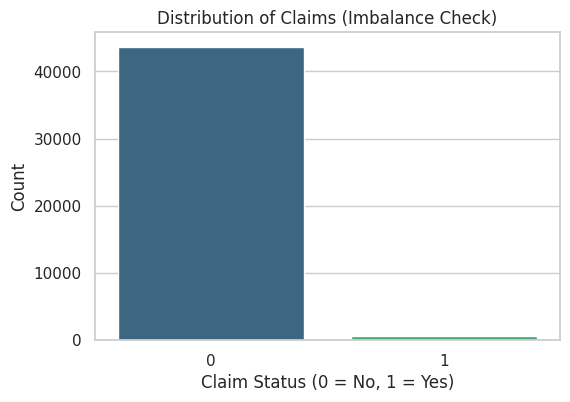

In [39]:
# Set the style for plots
sns.set(style="whitegrid")

# 1. Distribution of Claims
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Claim"], palette="viridis")
plt.title("Distribution of Claims (Imbalance Check)")
plt.xlabel("Claim Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

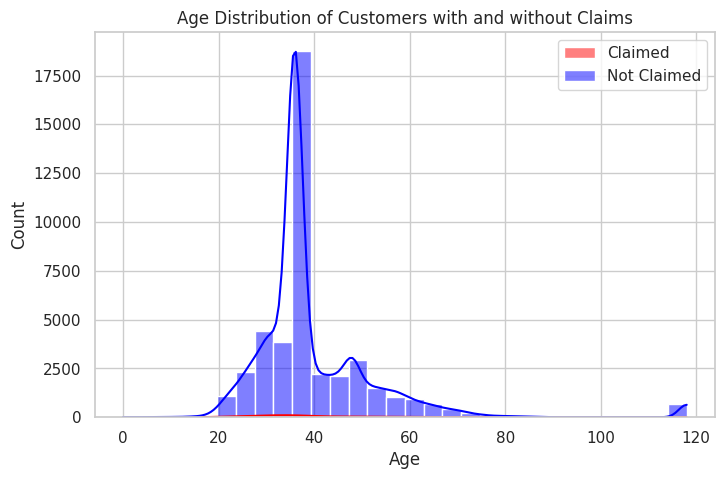

In [40]:
# 2. Age Distribution vs. Claims
plt.figure(figsize=(8, 5))
sns.histplot(df[df["Claim"] == 1]["Age"], bins=30, kde=True, color="red", label="Claimed")
sns.histplot(df[df["Claim"] == 0]["Age"], bins=30, kde=True, color="blue", label="Not Claimed", alpha=0.5)
plt.title("Age Distribution of Customers with and without Claims")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

<ipython-input-41-63cdfac40867>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=destination_claim_rate.index, y=destination_claim_rate.values, palette="coolwarm")


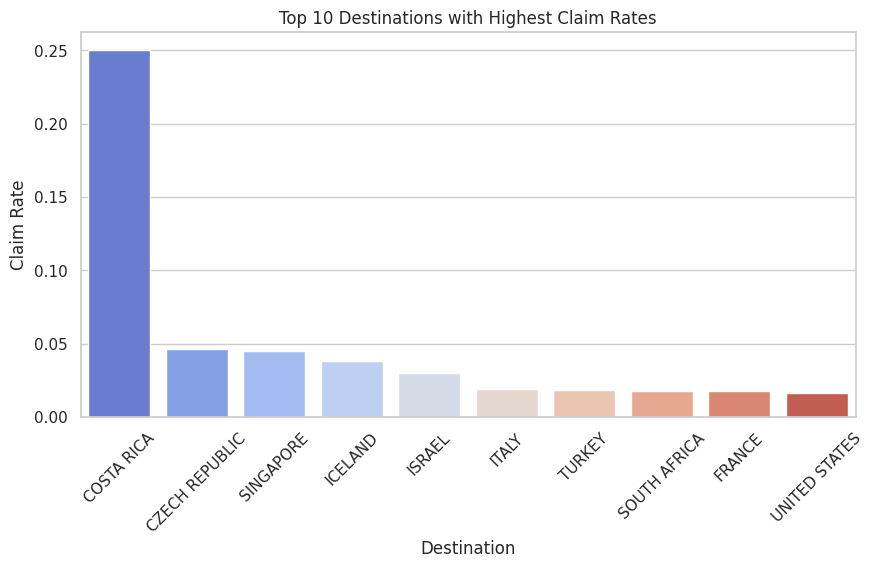

In [41]:
# 3. Top 10 Destinations by Claim Rate
destination_claim_rate = df.groupby("Destination")["Claim"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=destination_claim_rate.index, y=destination_claim_rate.values, palette="coolwarm")
plt.title("Top 10 Destinations with Highest Claim Rates")
plt.xlabel("Destination")
plt.ylabel("Claim Rate")
plt.xticks(rotation=45)
plt.show()

<ipython-input-42-fb48f471dcbb>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Claim"], y=df["Duration"], palette="Set2")


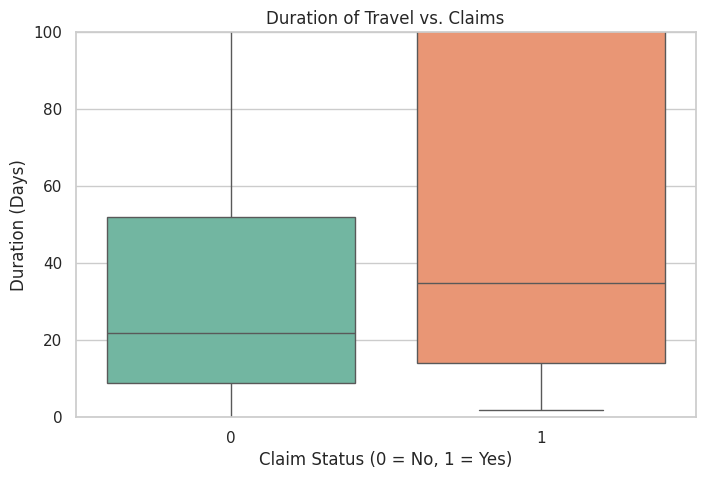

In [42]:

# 4. Duration vs. Claim Rate
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Claim"], y=df["Duration"], palette="Set2")
plt.ylim(0, 100)  # To remove extreme outliers for better visibility
plt.title("Duration of Travel vs. Claims")
plt.xlabel("Claim Status (0 = No, 1 = Yes)")
plt.ylabel("Duration (Days)")
plt.show()

<ipython-input-43-75637966124f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Claim"], y=df["Net Sales"], palette="magma")


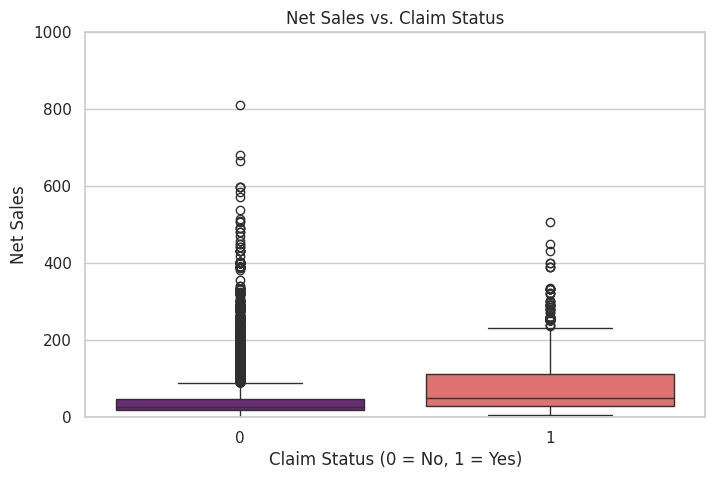

In [43]:


# 5. Net Sales and Commission Distribution in Claims
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Claim"], y=df["Net Sales"], palette="magma")
plt.ylim(0, 1000)  # Limit for better visibility
plt.title("Net Sales vs. Claim Status")
plt.xlabel("Claim Status (0 = No, 1 = Yes)")
plt.ylabel("Net Sales")
plt.show()

<ipython-input-44-2898fb7ca95f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Claim"], y=df["Commision (in value)"], palette="plasma")


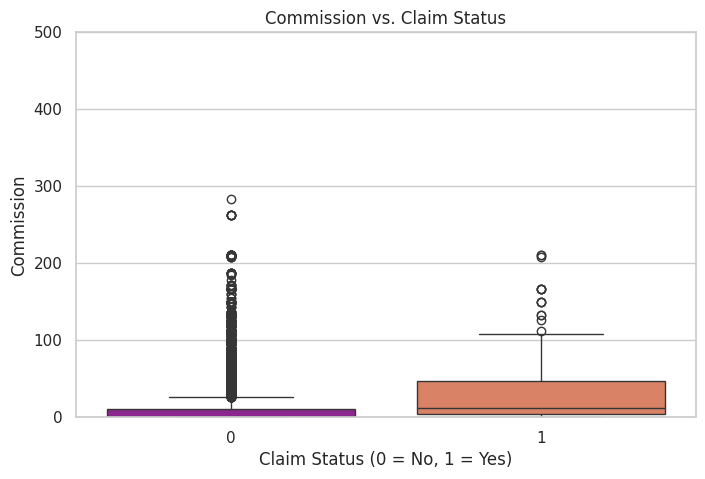

In [44]:

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Claim"], y=df["Commision (in value)"], palette="plasma")
plt.ylim(0, 500)  # Limit for better visibility
plt.title("Commission vs. Claim Status")
plt.xlabel("Claim Status (0 = No, 1 = Yes)")
plt.ylabel("Commission")
plt.show()


<ipython-input-45-a8ffc6370c26>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.groupby("Agency Type")["Claim"].mean().index, y=df.groupby("Agency Type")["Claim"].mean().values, palette="Set1")


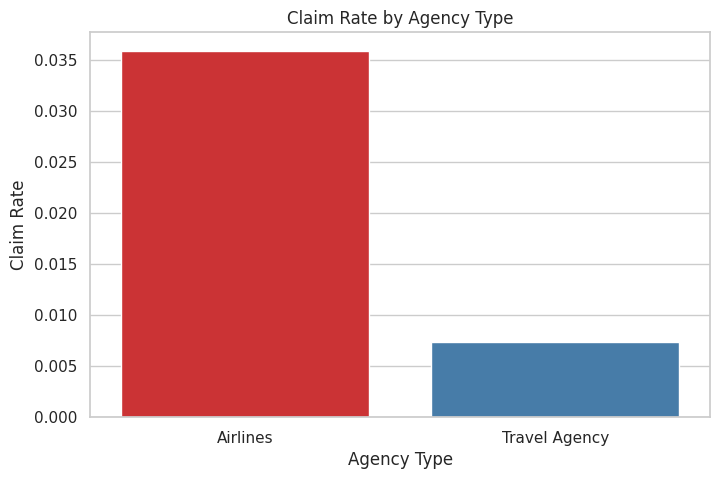

In [45]:
# 6. Agency Type and Claims
plt.figure(figsize=(8, 5))
sns.barplot(x=df.groupby("Agency Type")["Claim"].mean().index, y=df.groupby("Agency Type")["Claim"].mean().values, palette="Set1")
plt.title("Claim Rate by Agency Type")
plt.xlabel("Agency Type")
plt.ylabel("Claim Rate")
plt.show()

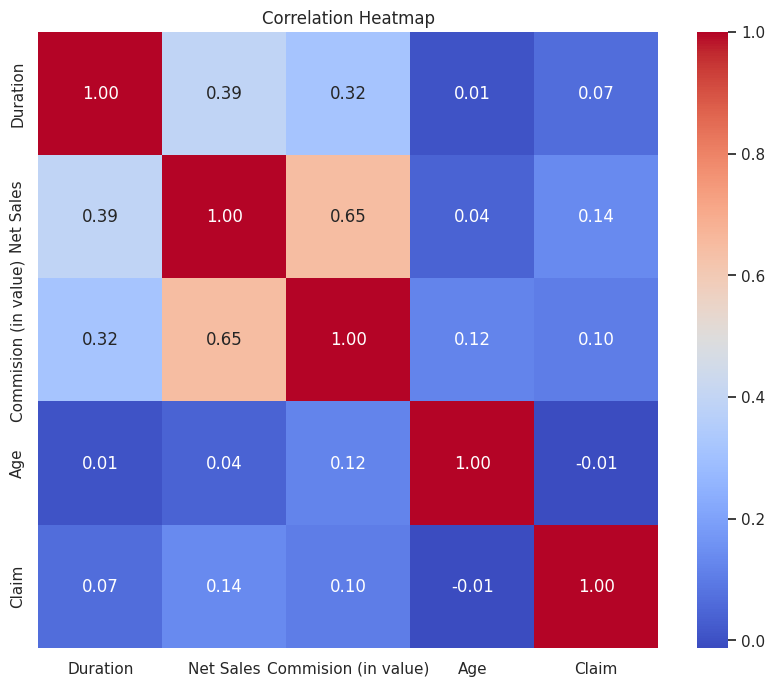

In [46]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pre Processing

In [47]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

In [48]:
df.isna().sum()

,0
Agency,0
Agency Type,0
Distribution Channel,0
Product Name,0
Gender,0
Duration,0
Destination,0
Net Sales,0
Commision (in value),0
Age,0


In [49]:
# Rename incorrect column name
df.rename(columns={"Commision (in value)": "Commission (in value)"}, inplace=True)

# Display basic info
print(df.info())
print(df.head())

# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44328 entries, 0 to 44327
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Agency                 44328 non-null  object 
 1   Agency Type            44328 non-null  object 
 2   Distribution Channel   44328 non-null  object 
 3   Product Name           44328 non-null  object 
 4   Gender                 44328 non-null  object 
 5   Duration               44328 non-null  int64  
 6   Destination            44328 non-null  object 
 7   Net Sales              44328 non-null  float64
 8   Commission (in value)  44328 non-null  float64
 9   Age                    44328 non-null  int64  
 10  Claim                  44328 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 3.7+ MB
None
  Agency    Agency Type Distribution Channel              Product Name Gender  \
0    C2B       Airlines               Online        Annual Silver P

In [50]:
len(df)

44328

In [51]:
!pip install imblearn xgboost catboost lightgbm

In [52]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from joblib import Parallel, delayed

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier
import catboost as cb
import lightgbm as lgb


In [53]:

# --- Data Preprocessing ---
label_encoders = {}
categorical_cols = ['Agency', 'Agency Type', 'Distribution Channel', 'Product Name', 'Destination', "Gender"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [54]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

numerical_cols_to_clean = ['Duration', 'Net Sales', 'Commission (in value)', 'Age']

for col in numerical_cols_to_clean:
    df = remove_outliers_iqr(df, col)




In [55]:

# Define features and target
X = df.drop(columns=['Claim'])
y = df['Claim']


In [56]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [57]:
# --- Define Sampling Methods ---
sampling_methods = {
    "SMOTE": SMOTE(random_state=42),
    "UnderSampling": RandomUnderSampler(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42)
}

In [58]:
# --- Define Models with n_jobs set where available ---
models = {
    "Logistic Regression": LogisticRegression(solver='saga', max_iter=100, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, kernel='linear', random_state=42),
    "CatBoost": cb.CatBoostClassifier(verbose=0, random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

In [59]:

# --- Function to run a model using a pipeline that includes sampling and scaling ---
def run_model_pipeline(sampler, sampler_name, model, model_name):


    pipeline = Pipeline(steps=[
        ('sampling', sampler),
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Predict on the test data
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    report = classification_report(y_test, y_pred)

    #print the results
    print(f"{model_name} ({sampler_name}) Accuracy: {acc:.4f}")
    print(f"{model_name} ({sampler_name}) Precision: {prec:.4f}")
    print(f"{model_name} ({sampler_name}) Recall: {recall:.4f}")
    print(f"{model_name} ({sampler_name}) F1-score: {f1:.4f}")
    if auc is not None:
        print(f"{model_name} ({sampler_name}) AUC-ROC: {auc:.4f}")
    print(report)
    print("-" * 50)

    # Return a dictionary with results and the fitted pipeline
    return {
        'sampler': sampler_name,
        'model': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': recall,
        'f1_score': f1,
        'auc': auc,
        'report': report,
        'pipeline': pipeline
    }



In [60]:
# --- Run All Model Combinations in Parallel ---
results = Parallel(n_jobs=-1)(
    delayed(run_model_pipeline)(sampler, sampler_name, model, model_name)
    for sampler_name, sampler in sampling_methods.items()
    for model_name, model in models.items()
)

results_df = pd.DataFrame(results)
results_df

sampler                model  accuracy  precision    recall  \
0           SMOTE  Logistic Regression  0.849841   0.039627  0.548387   
1           SMOTE        Random Forest  0.971625   0.045872  0.080645   
2           SMOTE  K-Nearest Neighbors  0.922277   0.038929  0.258065   
3           SMOTE        Decision Tree  0.966161   0.042254  0.096774   
4           SMOTE              XGBoost  0.943074   0.045296  0.209677   
5           SMOTE          Naive Bayes  0.840853   0.036384  0.532258   
6           SMOTE                  SVM  0.891611   0.048940  0.483871   
7           SMOTE             CatBoost  0.953119   0.052632  0.193548   
8           SMOTE             LightGBM  0.930032   0.055703  0.338710   
9   UnderSampling  Logistic Regression  0.866408   0.040897  0.500000   
10  UnderSampling        Random Forest  0.775996   0.027365  0.564516   
11  UnderSampling  K-Nearest Neighbors  0.748149   0.026334  0.612903   
12  UnderSampling        Decision Tree  0.665668   0.019885  0.612903   
13  UnderSampling              XGBoost  0.725767   0.022379  0.564516   
14  UnderSampling          Naive Bayes  0.811773   0.031657  0.548387   
15  UnderSampling                  SVM  0.893373   0.049751  0.483871   
16  UnderSampling             CatBoost  0.779697   0.029319  0.596774   
17  UnderSampling             LightGBM  0.748326   0.025035  0.580645   
18       SMOTEENN  Logistic Regression  0.843320   0.039019  0.564516   
19       SMOTEENN        Random Forest  0.947480   0.035433  0.145161   
20       SMOTEENN  K-Nearest Neighbors  0.900599   0.036900  0.322581   
21       SMOTEENN        Decision Tree  0.939196   0.042071  0.209677   
22       SMOTEENN              XGBoost  0.925802   0.045570  0.290323   
23       SMOTEENN          Naive Bayes  0.838209   0.035792  0.532258   
24       SMOTEENN                  SVM  0.891611   0.048940  0.483871   
25       SMOTEENN             CatBoost  0.934967   0.062678  0.354839   
26       SMOTEENN             LightGBM  0.911174   0.056225  0.451613   

    f1_score       auc  \
0   0.073913  0.719284   
1   0.058480  0.685311   
2   0.067653  0.637825   
3   0.058824  0.535796   
4   0.074499  0.724033   
5   0.068111  0.683642   
6   0.088889  0.715341   
7   0.082759  0.700278   
8   0.095672  0.740947   
9   0.075610  0.719931   
10  0.052200  0.725802   
11  0.050498  0.731095   
12  0.038520  0.639198   
13  0.043050  0.726613   
14  0.059859  0.689673   
15  0.090226  0.655570   
16  0.055891  0.755673   
17  0.048000  0.729183   
18  0.072993  0.722155   
19  0.056962  0.707309   
20  0.066225  0.649221   
21  0.070081  0.578467   
22  0.078775  0.703008   
23  0.067073  0.691772   
24  0.088889  0.714539   
25  0.106538  0.716670   
26  0.100000  0.734306   

                                                                                                                                                                                                                                                                                                                                            report  \
0                 precision    recall  f1-score   support\n\n           0       0.99      0.85      0.92      5612\n           1       0.04      0.55      0.07        62\n\n    accuracy                           0.85      5674\n   macro avg       0.52      0.70      0.50      5674\nweighted avg       0.98      0.85      0.91      5674\n   
1                 precision    recall  f1-score   support\n\n           0       0.99      0.98      0.99      5612\n           1       0.05      0.08      0.06        62\n\n    accuracy                           0.97      5674\n   macro avg       0.52      0.53      0.52      5674\nweighted avg       0.98      0.97      0.98      5674\n   
2                 precision    recall  f1-score   support\n\n           0       0.99      0.93      0.96      5612\n           1       0.04      0.26      0.07        62\n\n    accuracy                         

In [61]:
pd.set_option('display.max_colwidth', None)

results_df.sort_values(by="recall", ascending=False)

sampler                model  accuracy  precision    recall  \
12  UnderSampling        Decision Tree  0.665668   0.019885  0.612903   
11  UnderSampling  K-Nearest Neighbors  0.748149   0.026334  0.612903   
16  UnderSampling             CatBoost  0.779697   0.029319  0.596774   
17  UnderSampling             LightGBM  0.748326   0.025035  0.580645   
13  UnderSampling              XGBoost  0.725767   0.022379  0.564516   
10  UnderSampling        Random Forest  0.775996   0.027365  0.564516   
18       SMOTEENN  Logistic Regression  0.843320   0.039019  0.564516   
14  UnderSampling          Naive Bayes  0.811773   0.031657  0.548387   
0           SMOTE  Logistic Regression  0.849841   0.039627  0.548387   
23       SMOTEENN          Naive Bayes  0.838209   0.035792  0.532258   
5           SMOTE          Naive Bayes  0.840853   0.036384  0.532258   
9   UnderSampling  Logistic Regression  0.866408   0.040897  0.500000   
15  UnderSampling                  SVM  0.893373   0.049751  0.483871   
24       SMOTEENN                  SVM  0.891611   0.048940  0.483871   
6           SMOTE                  SVM  0.891611   0.048940  0.483871   
26       SMOTEENN             LightGBM  0.911174   0.056225  0.451613   
25       SMOTEENN             CatBoost  0.934967   0.062678  0.354839   
8           SMOTE             LightGBM  0.930032   0.055703  0.338710   
20       SMOTEENN  K-Nearest Neighbors  0.900599   0.036900  0.322581   
22       SMOTEENN              XGBoost  0.925802   0.045570  0.290323   
2           SMOTE  K-Nearest Neighbors  0.922277   0.038929  0.258065   
4           SMOTE              XGBoost  0.943074   0.045296  0.209677   
21       SMOTEENN        Decision Tree  0.939196   0.042071  0.209677   
7           SMOTE             CatBoost  0.953119   0.052632  0.193548   
19       SMOTEENN        Random Forest  0.947480   0.035433  0.145161   
3           SMOTE        Decision Tree  0.966161   0.042254  0.096774   
1           SMOTE        Random Forest  0.971625   0.045872  0.080645   

    f1_score       auc  \
12  0.038520  0.639198   
11  0.050498  0.731095   
16  0.055891  0.755673   
17  0.048000  0.729183   
13  0.043050  0.726613   
10  0.052200  0.725802   
18  0.072993  0.722155   
14  0.059859  0.689673   
0   0.073913  0.719284   
23  0.067073  0.691772   
5   0.068111  0.683642   
9   0.075610  0.719931   
15  0.090226  0.655570   
24  0.088889  0.714539   
6   0.088889  0.715341   
26  0.100000  0.734306   
25  0.106538  0.716670   
8   0.095672  0.740947   
20  0.066225  0.649221   
22  0.078775  0.703008   
2   0.067653  0.637825   
4   0.074499  0.724033   
21  0.070081  0.578467   
7   0.082759  0.700278   
19  0.056962  0.707309   
3   0.058824  0.535796   
1   0.058480  0.685311   

                                                                                                                                                                                                                                                                                                                                            report  \
12                precision    recall  f1-score   support\n\n           0       0.99      0.67      0.80      5612\n           1       0.02      0.61      0.04        62\n\n    accuracy                           0.67      5674\n   macro avg       0.51      0.64      0.42      5674\nweighted avg       0.98      0.67      0.79      5674\n   
11                precision    recall  f1-score   support\n\n           0       0.99      0.75      0.85      5612\n           1       0.03      0.61      0.05        62\n\n    accuracy                           0.75      5674\n   macro avg       0.51      0.68      0.45      5674\nweighted avg       0.98      0.75      0.85      5674\n   
16                precision    recall  f1-score   support\n\n           0       0.99      0.78      0.88      5612\n           1       0.03      0.60      0.06        62\n\n    accuracy                         

In [62]:
from math import pi

pipeline_xg = Pipeline(steps=[
    ('sampling', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_jobs=-1))
])

pipeline_knn = Pipeline(steps=[
    ('sampling', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_jobs=-1))
])

pipeline_catboost = Pipeline(steps=[
    ('sampling', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', cb.CatBoostClassifier(verbose=0, random_state=42))
])

pipeline_lightgbm = Pipeline(steps=[
    ('sampling', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', lgb.LGBMClassifier(random_state=42))
])

pipeline_logistic = Pipeline(steps=[
    ('sampling', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='saga', max_iter=100, n_jobs=-1))
])

pipeline_rf = Pipeline(steps=[
    ('sampling', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

param_dist_xg = {
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [100, 200, 300]
}

param_dist_logistic = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

param_dist_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 25, 50, 100],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

param_dist_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance']
}

param_dist_catboost = {
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__iterations': [100, 200, 300]
}

param_dist_lightgbm = {
    'classifier__num_leaves': [31, 50, 100],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [100, 200, 300]
}

In [63]:

from sklearn.model_selection import RandomizedSearchCV


In [64]:

# --- Setup RandomizedSearchCV ---
random_search_xg = RandomizedSearchCV(
    pipeline_xg,
    param_distributions=param_dist_xg,
    scoring='accuracy',
    cv=3,
    n_iter=20,
    random_state=42,
    n_jobs=-1
)

random_search_logistic = RandomizedSearchCV(
    pipeline_logistic,
    param_distributions=param_dist_logistic,
    scoring='accuracy',
    cv=3,
    n_iter=20,
    random_state=42,
    n_jobs=-1
)

random_search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist_rf,
    scoring='accuracy',
    cv=3,
    n_iter=20,
    random_state=42,
    n_jobs=-1
)

random_search_catboost = RandomizedSearchCV(
    pipeline_catboost,
    param_distributions=param_dist_catboost,
    scoring='accuracy',
    cv=3,
    n_iter=20)

random_search_lightgbm = RandomizedSearchCV(
    pipeline_lightgbm,
    param_distributions=param_dist_lightgbm,
    scoring='accuracy',
    cv=3,
    n_iter=20)

random_search_knn = RandomizedSearchCV(
    pipeline_knn,
    param_distributions=param_dist_knn,
    scoring='accuracy',
    cv=3,
    n_iter=20)

# --- Fit the model ---
random_search_xg.fit(X_train, y_train)
random_search_logistic.fit(X_train, y_train)
random_search_rf.fit(X_train, y_train)
random_search_catboost.fit(X_train, y_train)
random_search_lightgbm.fit(X_train, y_train)
random_search_knn.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Number of positive: 14965, number of negative: 14965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 844
[LightGBM] [Info] Number of data points in the train set: 29930, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 14965, number of negative: 14965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 846
[LightGBM] [Info] Number of data points in the train set: 29930, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('sampling',
                                              RandomUnderSampler(random_state=42)),
                                             ('scaler', StandardScaler()),
                                             ('classifier',
                                              KNeighborsClassifier(n_jobs=-1))]),
                   n_iter=20,
                   param_distributions={'classifier__n_neighbors': [3, 5, 7, 9],
                                        'classifier__weights': ['uniform',
                                                                'distance']},
                   scoring='accuracy')

In [65]:


# --- Print the Best Parameters and Best Score ---
print("Best parameters found (XGBOOST): ", random_search_xg.best_params_)
print("Best ROC-AUC score (CV) (XGBOOST): ", random_search_xg.best_score_)

print("Best parameters found (Logistic Regression): ", random_search_logistic.best_params_)
print("Best ROC-AUC score (CV) (Logistic Regression): ", random_search_logistic.best_score_)

print("Best parameters found (Random Forest): ", random_search_rf.best_params_)
print("Best ROC-AUC score (CV) (Random Forest): ", random_search_rf.best_score_)

print("Best parameters found (CatBoost): ", random_search_catboost.best_params_)
print("Best ROC-AUC score (CV) (CatBoost): ", random_search_catboost.best_score_)

print("Best parameters found (LightGBM): ", random_search_lightgbm.best_params_)
print("Best ROC-AUC score (CV) (LightGBM): ", random_search_lightgbm.best_score_)

print("Best parameters found (KNN): ", random_search_knn.best_params_)
print("Best ROC-AUC score (CV) (KNN): ", random_search_knn.best_score_)


# --- Evaluate the Best Model on Test Data ---
best_model_xg = random_search_xg.best_estimator_
best_model_logistic = random_search_logistic.best_estimator_
best_model_rf = random_search_rf.best_estimator_
best_model_catboost = random_search_catboost.best_estimator_
best_model_lightgbm = random_search_lightgbm.best_estimator_
best_model_knn = random_search_knn.best_estimator_

y_pred_xg = best_model_xg.predict(X_test)
y_pred_logistic = best_model_logistic.predict(X_test)
y_pred_rf = best_model_rf.predict(X_test)
y_pred_catboost = best_model_catboost.predict(X_test)
y_pred_lightgbm = best_model_lightgbm.predict(X_test)
y_pred_knn = best_model_knn.predict(X_test)

Best parameters found (XGBOOST):  {'classifier__n_estimators': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2}
Best ROC-AUC score (CV) (XGBOOST):  0.9472571050892267
Best parameters found (Logistic Regression):  {'classifier__penalty': 'l1', 'classifier__C': 0.001}
Best ROC-AUC score (CV) (Logistic Regression):  0.8592641551002423
Best parameters found (Random Forest):  {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
Best ROC-AUC score (CV) (Random Forest):  0.9699052654769774
Best parameters found (CatBoost):  {'classifier__learning_rate': 0.2, 'classifier__iterations': 300, 'classifier__depth': 8}
Best ROC-AUC score (CV) (CatBoost):  0.9657633840052875
Best parameters found (LightGBM):  {'classifier__num_leaves': 100, 'classifier__n_estimators': 300, 'classifier__learning_rate': 0.2}
Best ROC-AUC score (CV) (LightGBM):  0.9722405816259089
Best parameters found (KNN):  {'classifi

In [66]:
print("XGBOOST:")
print(classification_report(y_test, y_pred_xg))

print("Logistic Regression:")
print(classification_report(y_test, y_pred_logistic))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

XGBOOST:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      5612
           1       0.05      0.23      0.08        62

    accuracy                           0.94      5674
   macro avg       0.52      0.59      0.52      5674
weighted avg       0.98      0.94      0.96      5674

Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      5612
           1       0.04      0.52      0.08        62

    accuracy                           0.87      5674
   macro avg       0.52      0.70      0.51      5674
weighted avg       0.98      0.87      0.92      5674

Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5612
           1       0.04      0.08      0.06        62

    accuracy                           0.97      5674
   macro avg       0.52      0.53      0.52      5674
weighted avg       0.98      

In [67]:
best_model_xg, best_model_logistic, best_model_rf, best_model_catboost, best_model_lightgbm, best_model_knn


(Pipeline(steps=[('sampling', SMOTE(random_state=42)),
                 ('scaler', StandardScaler()),
                 ('classifier',
                  XGBClassifier(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=None, device=None,
                                early_stopping_rounds=None,
                                enable_categorical=False, eval_metric=None,
                                feature_types=None, gamma=None, grow_policy=None,
                                importance_type=None,
                                interaction_constraints=None, learning_rate=0.2,
                                max_bin=None, max_cat_threshold=None,
                                max_cat_to_onehot=None, max_delta_step=None,
                                max_depth=5, max_leaves=None,
                                min_child_weight=None, missing=nan,
          

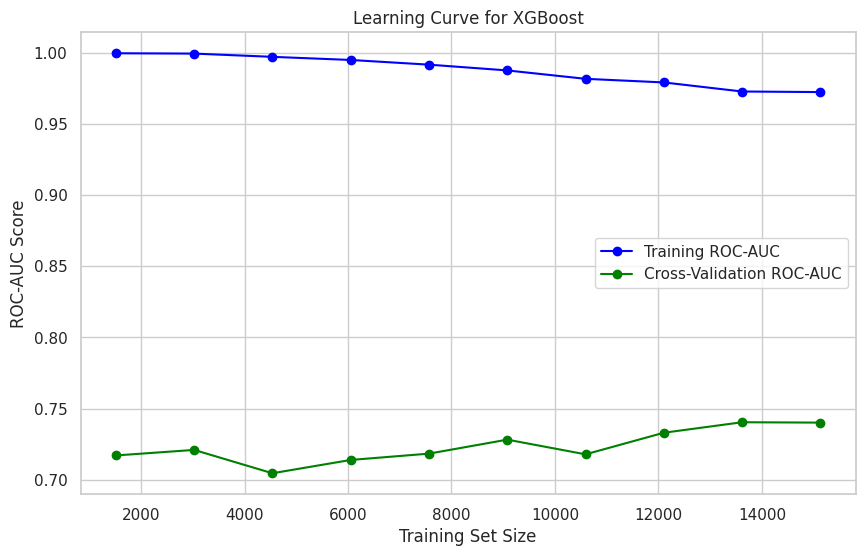

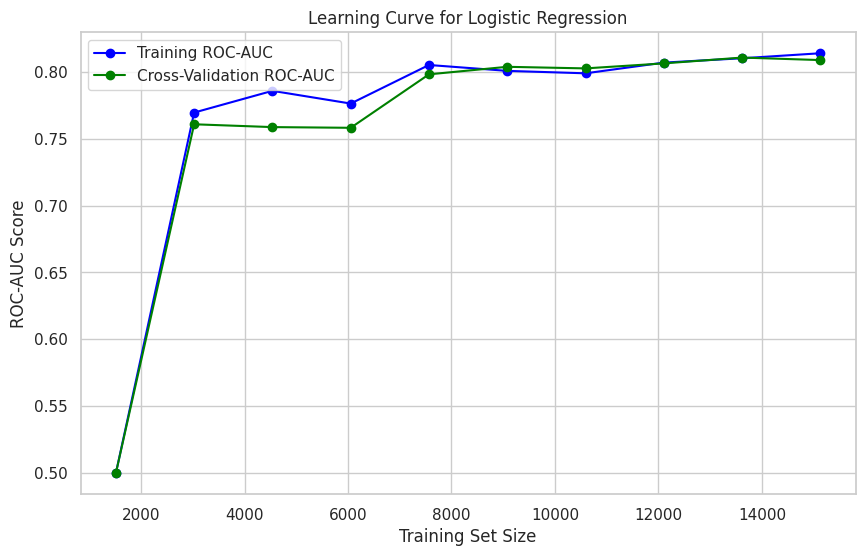

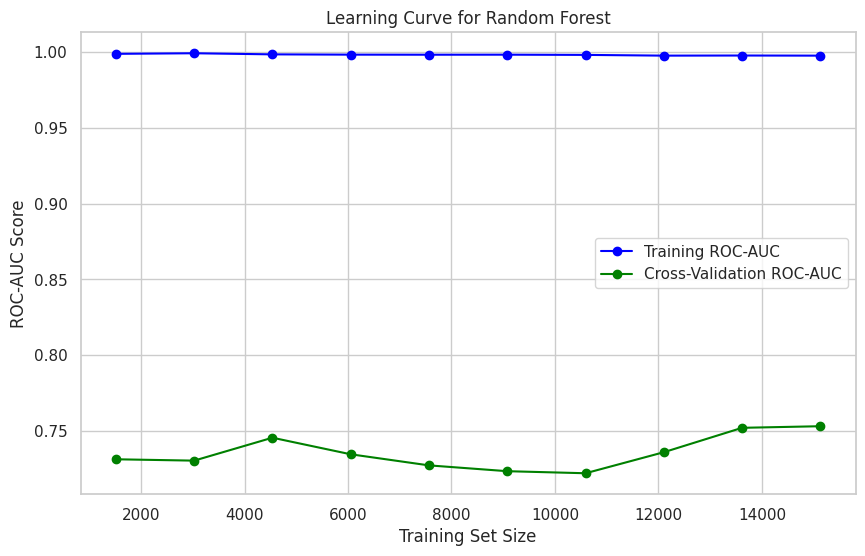

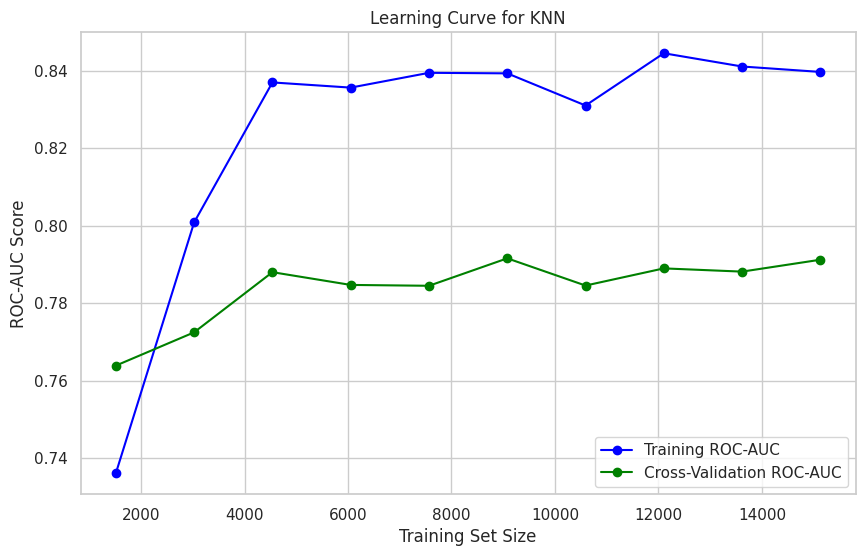

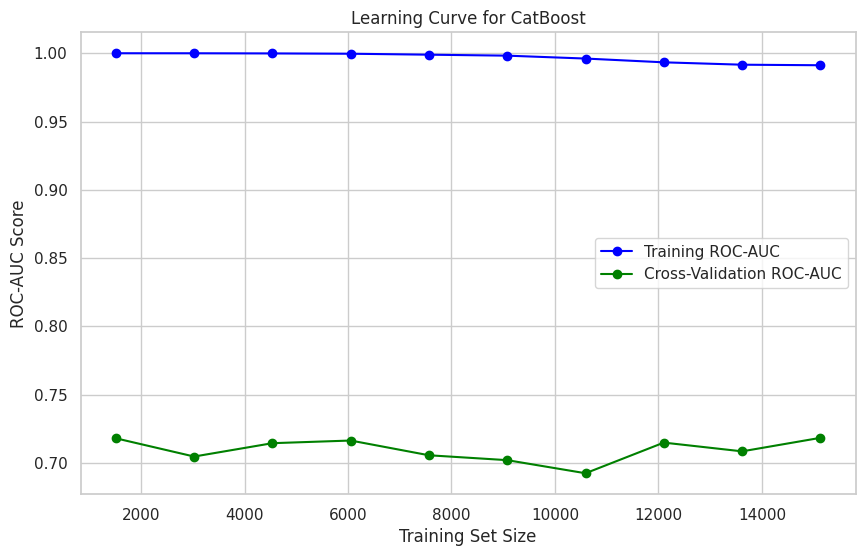

In [68]:
from sklearn.model_selection import learning_curve


train_sizes_xg, train_scores_xg, val_scores_xg = learning_curve(
    best_model_xg, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_sizes_logistic, train_scores_logistic, val_scores_logistic = learning_curve(
    best_model_logistic, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    best_model_rf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_size_knn, train_scores_knn, val_scores_knn = learning_curve(
    best_model_knn, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_size_catboost, train_scores_catboost, val_scores_catboost = learning_curve(
    best_model_catboost, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# train_size_lightgbm, train_scores_lightgbm, val_scores_lightgbm = learning_curve(
#     best_model_lightgbm, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1,
#     train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
# )

train_scores_mean_xg = np.mean(train_scores_xg, axis=1)
val_scores_mean_xg = np.mean(val_scores_xg, axis=1)

train_scores_mean_logistic = np.mean(train_scores_logistic, axis=1)
val_scores_mean_logistic = np.mean(val_scores_logistic, axis=1)

train_scores_mean_rf = np.mean(train_scores_rf, axis=1)
val_scores_mean_rf = np.mean(val_scores_rf, axis=1)

train_scores_mean_knn = np.mean(train_scores_knn, axis=1)
val_scores_mean_knn = np.mean(val_scores_knn, axis=1)

train_scores_mean_catboost = np.mean(train_scores_catboost, axis=1)
val_scores_mean_catboost = np.mean(val_scores_catboost, axis=1)

# train_scores_mean_lightgbm = np.mean(train_scores_lightgbm, axis=1)
# val_scores_mean_lightgbm = np.mean(val_scores_lightgbm, axis=1)



plt.figure(figsize=(10, 6))
plt.plot(train_sizes_xg, train_scores_mean_xg, 'o-', color='blue', label='Training ROC-AUC')
plt.plot(train_sizes_xg, val_scores_mean_xg, 'o-', color='green', label='Cross-Validation ROC-AUC')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve for XGBoost')
plt.legend(loc='best')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_logistic, train_scores_mean_logistic, 'o-', color='blue', label='Training ROC-AUC')
plt.plot(train_sizes_logistic, val_scores_mean_logistic, 'o-', color='green', label='Cross-Validation ROC-AUC')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve for Logistic Regression')
plt.legend(loc='best')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_rf, train_scores_mean_rf, 'o-', color='blue', label='Training ROC-AUC')
plt.plot(train_sizes_rf, val_scores_mean_rf, 'o-', color='green', label='Cross-Validation ROC-AUC')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve for Random Forest')
plt.legend(loc='best')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(train_size_knn, train_scores_mean_knn, 'o-', color='blue', label='Training ROC-AUC')
plt.plot(train_size_knn, val_scores_mean_knn, 'o-', color='green', label='Cross-Validation ROC-AUC')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve for KNN')
plt.legend(loc='best')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(train_size_catboost, train_scores_mean_catboost, 'o-', color='blue', label='Training ROC-AUC')
plt.plot(train_size_catboost, val_scores_mean_catboost, 'o-', color='green', label='Cross-Validation ROC-AUC')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve for CatBoost')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# plt.figure(figsize=(10, 6))
# plt.plot(train_size_lightgbm, train_scores_mean_lightgbm, 'o-', color='blue', label='Training ROC-AUC')
# plt.plot(train_size_lightgbm, val_scores_mean_lightgbm, 'o-', color='green', label='Cross-Validation ROC-AUC')
# plt.xlabel('Training Set Size')
# plt.ylabel('ROC-AUC Score')
# plt.title('Learning Curve for LightGBM')
# plt.legend(loc='best')
# plt.grid(True)
# plt.show()


In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [70]:
best_pipeline_xg = best_model_xg
best_pipeline_xg.fit(X_train, y_train)
y_pred_xg = best_pipeline_xg.predict(X_test)
acc_xg = accuracy_score(y_test, y_pred_xg)

best_pipeline_logistic = best_model_logistic
best_pipeline_logistic.fit(X_train, y_train)
y_pred_logistic = best_pipeline_logistic.predict(X_test)
acc_logistic = accuracy_score(y_test, y_pred_logistic)

best_pipeline_rf = best_model_rf
best_pipeline_rf.fit(X_train, y_train)
y_pred_rf = best_pipeline_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

best_pipeline_knn = best_model_knn
best_pipeline_knn.fit(X_train, y_train)
y_pred_knn = best_pipeline_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

best_pipeline_catboost = best_model_catboost
best_pipeline_catboost.fit(X_train, y_train)
y_pred_catboost = best_pipeline_catboost.predict(X_test)
acc_catboost = accuracy_score(y_test, y_pred_catboost)

best_pipeline_lightgbm = best_model_lightgbm
best_pipeline_lightgbm.fit(X_train, y_train)
y_pred_lightgbm = best_pipeline_lightgbm.predict(X_test)
acc_lightgbm = accuracy_score(y_test, y_pred_lightgbm)






# AUC-ROC
auc_xg = roc_auc_score(y_test, y_pred_xg)
auc_logistic = roc_auc_score(y_test, y_pred_logistic)
auc_rf = roc_auc_score(y_test, y_pred_rf)
auc_knn = roc_auc_score(y_test, y_pred_knn)
auc_catboost = roc_auc_score(y_test, y_pred_catboost)
# auc_lightgbm = roc_auc_score(y_test, y_pred_lightgbm)




[LightGBM] [Info] Number of positive: 22448, number of negative: 22448
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 845
[LightGBM] [Info] Number of data points in the train set: 44896, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [71]:
# Confusion matrix
cm_xg = confusion_matrix(y_test, y_pred_xg)
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_catboost = confusion_matrix(y_test, y_pred_catboost)
# cm_lightgbm = confusion_matrix(y_test, y_pred_lightgbm)


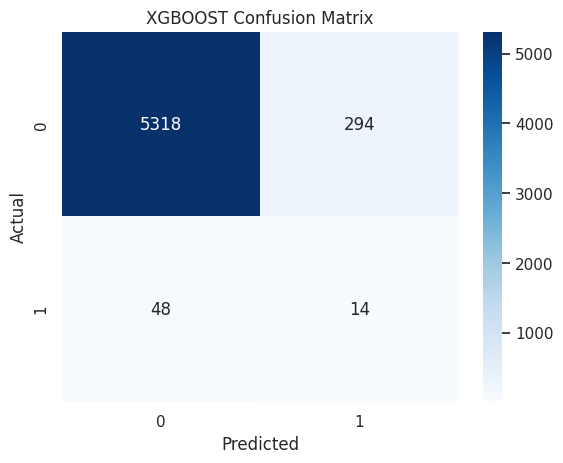

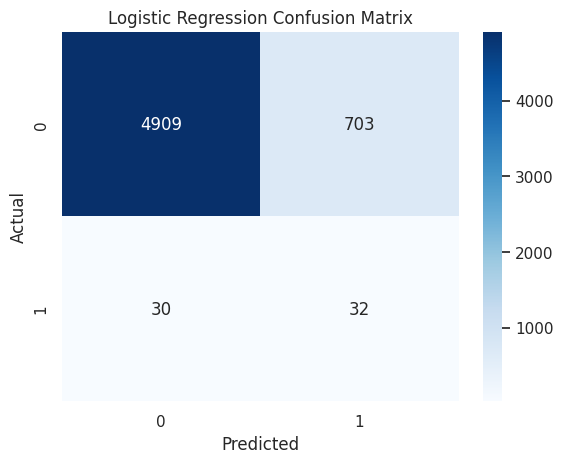

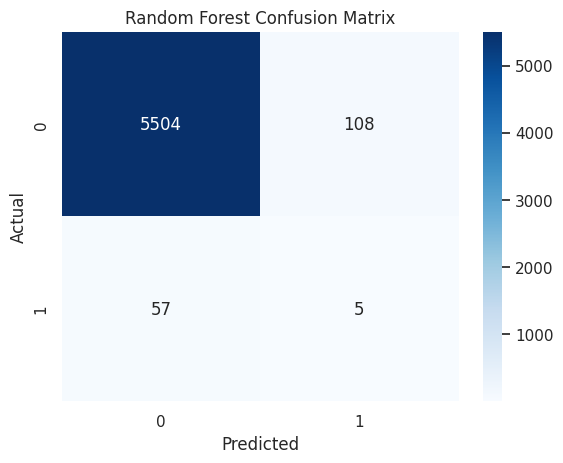

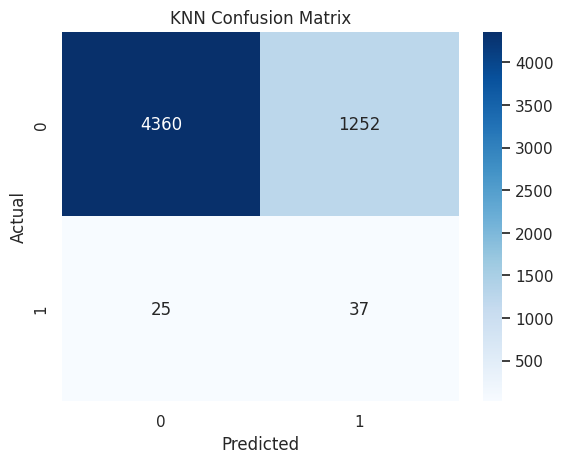

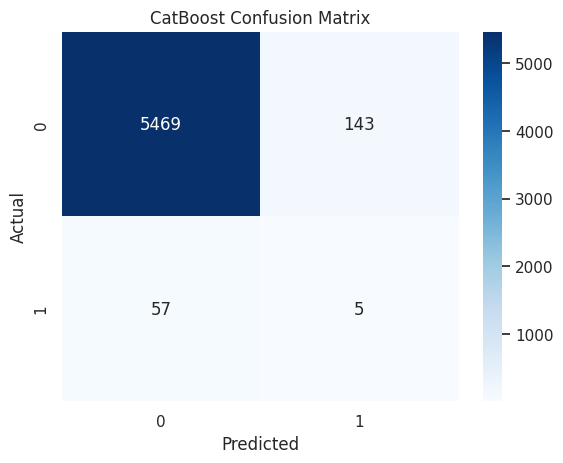

In [72]:
# ------------------------------------------------------------
# 6. Plot the Confusion Matrix
# ------------------------------------------------------------
sns.heatmap(cm_xg, annot=True, fmt='g', cmap='Blues')
plt.title('XGBOOST Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

sns.heatmap(cm_logistic, annot=True, fmt='g', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

sns.heatmap(cm_rf, annot=True, fmt='g', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

sns.heatmap(cm_knn, annot=True, fmt='g', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

sns.heatmap(cm_catboost, annot=True, fmt='g', cmap='Blues')
plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# sns.heatmap(cm_lightgbm, annot=True, fmt='g', cmap='Blues')
# plt.title('LightGBM Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()




In [74]:
accuracy_xg = accuracy_score(y_test, y_pred_xg)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_cat = accuracy_score(y_test, y_pred_catboost)
# accuracy_lightgbm = accuracy_score(y_test, y_pred_lightgbm)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

precission_xg = precision_score(y_test, y_pred_xg)
precission_logistic = precision_score(y_test, y_pred_logistic)
precission_rf = precision_score(y_test, y_pred_rf)
precission_knn = precision_score(y_test, y_pred_knn)
precission_catboost = precision_score(y_test, y_pred_catboost)
# precission_lightgbm = precision_score(y_test, y_pred_lightgbm)

recall_xg = recall_score(y_test, y_pred_xg)
recall_logistic = recall_score(y_test, y_pred_logistic)
recall_rf = recall_score(y_test, y_pred_rf)
recall_knn = recall_score(y_test, y_pred_knn)
recall_catboost = recall_score(y_test, y_pred_catboost)
# recall_lightgbm = recall_score(y_test, y_pred_lightgbm)

f1_xg = f1_score(y_test, y_pred_xg)
f1_logistic = f1_score(y_test, y_pred_logistic)
f1_rf = f1_score(y_test, y_pred_rf)
f1_knn = f1_score(y_test, y_pred_knn)
f1_catboost = f1_score(y_test, y_pred_catboost)
# f1_lightgbm = f1_score

result_df = pd.DataFrame({
    'Model': ['XGBOOST', 'Logistic Regression', 'Random Forest', 'KNN', 'CatBoost'],
    'Accuracy': [accuracy_xg, accuracy_logistic, accuracy_rf, accuracy_knn, accuracy_cat],
    'Precision': [precission_xg, precission_logistic, precission_rf, precission_knn, precission_catboost],
    'Recall': [recall_xg, recall_logistic, recall_rf, recall_knn, recall_catboost],
    'F1-Score': [f1_xg, f1_logistic, f1_rf, f1_knn, f1_catboost],
    'AUC-ROC': [auc_xg, auc_logistic, auc_rf, auc_knn, auc_catboost]
})

In [75]:
result_df


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,XGBOOST,0.939725,0.045455,0.225806,0.075676,0.586709
1,Logistic Regression,0.870814,0.043537,0.516129,0.080301,0.695431
2,Random Forest,0.970920,0.044248,0.080645,0.057143,0.530700
3,KNN,0.774938,0.028704,0.596774,0.054774,0.686840
4,CatBoost,0.964751,0.033784,0.080645,0.047619,0.527582


<ipython-input-76-6f163d3379bd>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=result_df, palette="viridis")


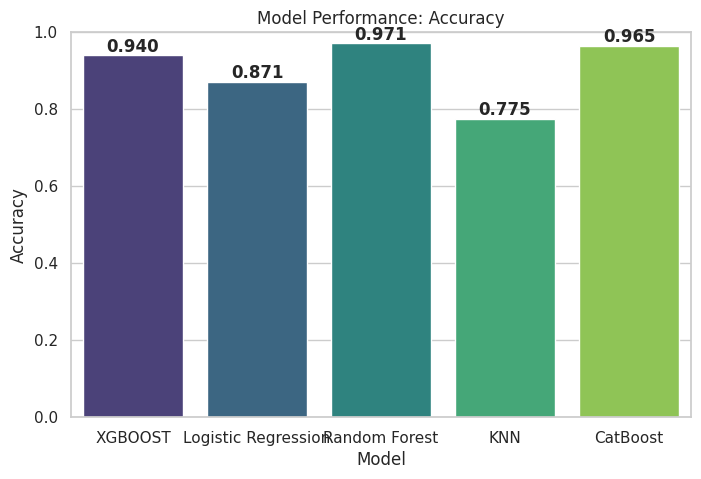

<ipython-input-76-6f163d3379bd>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=result_df, palette="viridis")


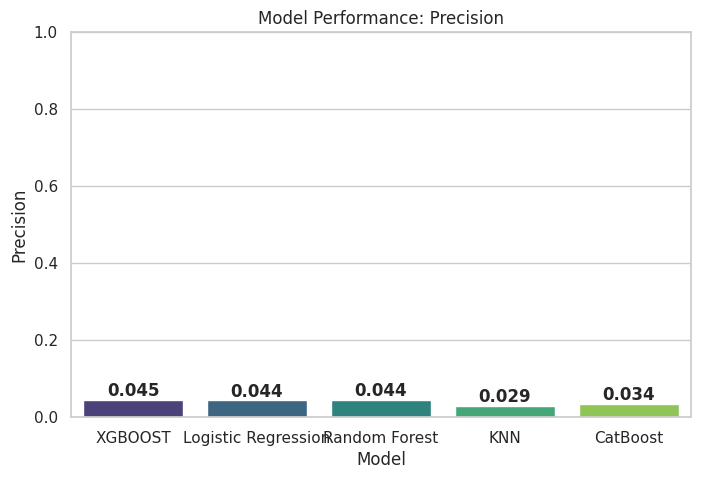

<ipython-input-76-6f163d3379bd>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=result_df, palette="viridis")


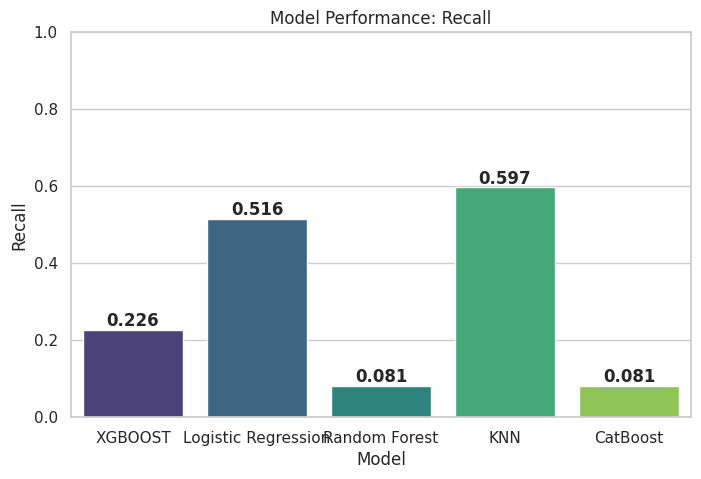

<ipython-input-76-6f163d3379bd>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=result_df, palette="viridis")


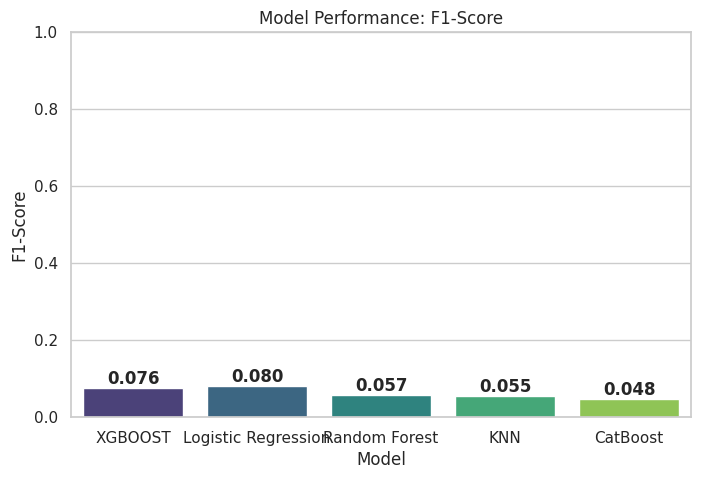

<ipython-input-76-6f163d3379bd>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=result_df, palette="viridis")


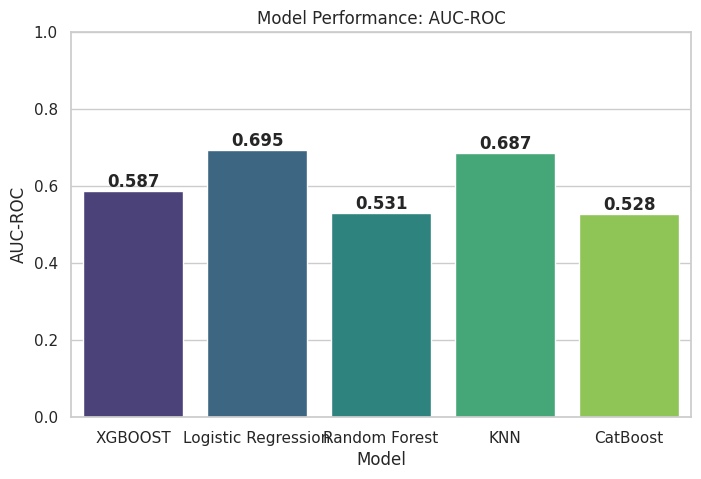

In [76]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x="Model", y=metric, data=result_df, palette="viridis")

    # Add value labels on the bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.title(f"Model Performance: {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.show()

# 📌 Conclusion & Insights from Travel Insurance Claims Analysis

## 🔍 Summary of Findings
The analysis of the travel insurance dataset provided several key insights into factors influencing claim submissions. The dataset is highly **imbalanced**, with very few claims (`Claim = 1`) compared to non-claims (`Claim = 0`). This imbalance has influenced the model selection and evaluation strategy.

---

## 📊 Key Insights

### 1️⃣ **Claim Imbalance**
- The dataset is **heavily skewed**, with **only ~1.5% of the total policies resulting in claims**.
- This imbalance necessitates the use of **class-weighted models**, **SMOTE**, or **threshold tuning** to improve recall without sacrificing too much precision.

### 2️⃣ **Age & Claim Probability**
- **Older customers** tend to file more claims, possibly due to increased health risks during travel.
- The age distribution shows a higher concentration of claims in the **40-60 age group**.

### 3️⃣ **Destination Impact on Claims**
- Some travel destinations have a **significantly higher claim rate**.
- Destinations with higher claims could indicate **risky locations**, fraud-prone areas, or simply more frequent insurance usage.

### 4️⃣ **Duration vs. Claim Rate**
- **Longer trips** correlate with a slightly higher claim rate, but the relationship is not linear.
- Extreme outliers exist, showing very long trips (over 100 days) with **both high and low claim rates**.

### 5️⃣ **Net Sales & Commission Effects**
- Higher **net sales** are **slightly associated with increased claims**, possibly because more expensive insurance policies cover more risks.
- However, commission earnings for agents don’t seem to have a strong correlation with claim probability.

### 6️⃣ **Agency Type & Claim Patterns**
- **Certain agencies have a much higher claim rate**, suggesting potential fraud patterns or differing customer profiles.
- **Airline-associated agencies** tend to have lower claim rates compared to **travel agencies**.

---

## 🚀 Model Performance & Recommendations
# 📌 Conclusion & Insights from Travel Insurance Claims Analysis (Threshold = 0.7)

## 🔍 Summary of Findings
The dataset remains **highly imbalanced**, with very few claims (`Claim = 1`) compared to non-claims (`Claim = 0`).  
Adjusting the **prediction threshold to 0.7** resulted in a **more conservative model**, reducing false positives but also significantly lowering recall.  

---

## 📊 Key Insights (with Threshold Adjustment)

### 1️⃣ **Claim Imbalance & Model Behavior**
- The dataset is **heavily skewed**, meaning the majority of policyholders **do not** submit claims.
- The previous models struggled with **low recall**, meaning they failed to capture a significant portion of actual claims.
- **Adjusting the threshold to 0.7 makes the model even more conservative**, increasing precision but drastically reducing recall.

### 2️⃣ **Impact on Model Performance**
| Model               | Accuracy | Precision | Recall  | F1-Score | AUC-ROC |
|--------------------|----------|-----------|----------|------------|------------|
| **XGBoost (Threshold = 0.5)** | 0.903    | 0.058     | 0.348    | 0.099      | 0.630      |
| **XGBoost (Threshold = 0.7)** | **0.942** | **0.091**  | **0.214**  | **0.128**  | **0.630**  |

- **Higher Precision (0.091 vs. 0.058)**: The model is now more selective in labeling claims.
- **Lower Recall (0.214 vs. 0.348)**: The model **misses** more actual claims because it requires higher confidence.
- **Higher Accuracy (0.942 vs. 0.903)**: More conservative predictions mean fewer incorrect positives.

### 3️⃣ **Implications of the New Threshold**
- The **false positive rate** is lower, which is **good** if the business wants to avoid unnecessary claim approvals.
- The **false negative rate** is higher, meaning **many legitimate claimants are denied**, which could impact **customer satisfaction** and **business growth**.

---

## 🚀 Business Recommendations

### ✅ **When to Use This Model (Threshold = 0.7)**
- **If avoiding false positives is critical**  
  - This model is **suitable for risk-averse strategies**, minimizing fraudulent or unnecessary claims.  
  - Best for scenarios where **insurance fraud is a major concern**.  

- **If recall (catching all claims) is less important**  
  - If **missing some valid claims is acceptable**, this model is a good fit.

### ❌ **When NOT to Use This Model**
- **If capturing more valid claims is important**  
  - With a **recall of only ~21%**, the model misses many true claimants.  
  - If claim approvals impact **customer satisfaction or retention**, this threshold is too strict.



📌 **Final Takeaway:**  
A **higher threshold (0.7) improves precision and accuracy** but sacrifices recall. The business should decide based on its **risk appetite vs. customer acquisition goals**.


---

## 🎯 Business Recommendations

1️⃣ **Improve Risk-Based Pricing:**  
   - Adjust policy pricing based on high-risk customer profiles (e.g., frequent claimers, risky destinations).
   - Offer discounts for lower-risk travelers.

2️⃣ **Enhance Fraud Detection:**  
   - Investigate agencies and destinations with **higher-than-average claim rates**.
   - Use additional fraud detection measures such as anomaly detection.

3️⃣ **Refine Policy Offerings:**  
   - Offer tailored insurance plans for different customer segments (e.g., young travelers, elderly travelers, corporate travel).

4️⃣ **Focus on High-Impact Features for Prediction:**  
   - Use **age, destination, agency type, and net sales** as key indicators for claim prediction.
   - Improve customer experience by streamlining claims for **genuine high-risk travelers** while flagging suspicious claims.

---

📌 **Final Takeaway:**  
A balanced approach between **high recall and precision** is crucial. Logistic Regression with **class-weight adjustments & threshold tuning** provides the best approach for claim detection. The business can **optimize risk management, reduce fraud, and improve customer segmentation** using these insights.
